# XGBoost Prediction Plots

This notebook loads the saved XGBoost pipeline artifact, evaluates it on the test split, and saves two plots:

1. Actual vs. Predicted scatter plot (color-coded by price band).
2. Prediction accuracy by price band (actual vs. predicted median prices).

In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

def ensure_project_root() -> Path:
    """Find the repo root whether Jupyter starts in repo root or notebooks/."""
    cwd = Path.cwd().resolve()
    for root in (cwd, *cwd.parents):
        if (root / "pricing_lab" / "__init__.py").is_file():
            root_str = str(root)
            if root_str not in sys.path:
                sys.path.insert(0, root_str)
            return root
    raise RuntimeError("Could not find project root containing pricing_lab.")


PROJECT_ROOT = ensure_project_root()

from pricing_lab.data import load_train_test

In [2]:
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
MODEL_PATH = MODEL_DIR / "xgboost.joblib"
MODEL_METADATA_PATH = MODEL_PATH.with_suffix(".json")
PLOTS_DIR = PROJECT_ROOT / "artifacts/plots"
SCATTER_PLOT_PATH = PLOTS_DIR / "xgboost_actual_vs_predicted_by_band.png"
BAND_BAR_PLOT_PATH = PLOTS_DIR / "xgboost_prediction_accuracy_by_band.png"
BAND_LABELS = ["Low", "Mid", "High"]
BAND_COLORS = {
    "Low": "#2ca02c",
    "Mid": "#1f77b4",
    "High": "#d62728",
}

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Missing model artifact at {MODEL_PATH}. Run training with --model-output-dir artifacts/models first."
    )

print(f"Loading XGBoost artifact from {MODEL_PATH}")
if MODEL_METADATA_PATH.exists():
    print(f"Found checkpoint metadata at {MODEL_METADATA_PATH}")

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
data = load_train_test()
xgboost_pipeline = joblib.load(MODEL_PATH)
predicted_log_prices = np.asarray(xgboost_pipeline.predict(data.X_test), dtype=np.float64)
raw_prediction_median = float(np.median(predicted_log_prices))
if not 2.0 <= raw_prediction_median <= 7.0:
    raise ValueError(
        "Expected XGBoost predictions on log1p(price) scale, but median raw prediction "
        f"was {raw_prediction_median:.3f}. Check MODEL_PATH and rerun with the ml-optimized kernel."
    )

actual_prices = np.expm1(data.y_test.to_numpy(dtype=np.float64))
predicted_prices = np.expm1(predicted_log_prices)
print(
    "Median prices: "
    f"actual=${np.median(actual_prices):.2f}, predicted=${np.median(predicted_prices):.2f}"
)

evaluation_frame = pd.DataFrame(
    {
        "actual_price": actual_prices,
        "predicted_price": predicted_prices,
    }
)
evaluation_frame["price_band"] = pd.qcut(
    evaluation_frame["actual_price"],
    q=3,
    labels=BAND_LABELS,
)
evaluation_frame.head()

Loading XGBoost artifact from /Users/Kushal/Projects/BNB_Pricing/artifacts/models/xgboost.joblib
Found checkpoint metadata at /Users/Kushal/Projects/BNB_Pricing/artifacts/models/xgboost.json
Median prices: actual=$100.00, predicted=$107.73


,actual_price,predicted_price,price_band
0,150.0,84.778746,High
1,50.0,87.170409,Low
2,28.0,100.983611,Low
3,120.0,147.680765,Mid
4,50.0,67.043495,Low


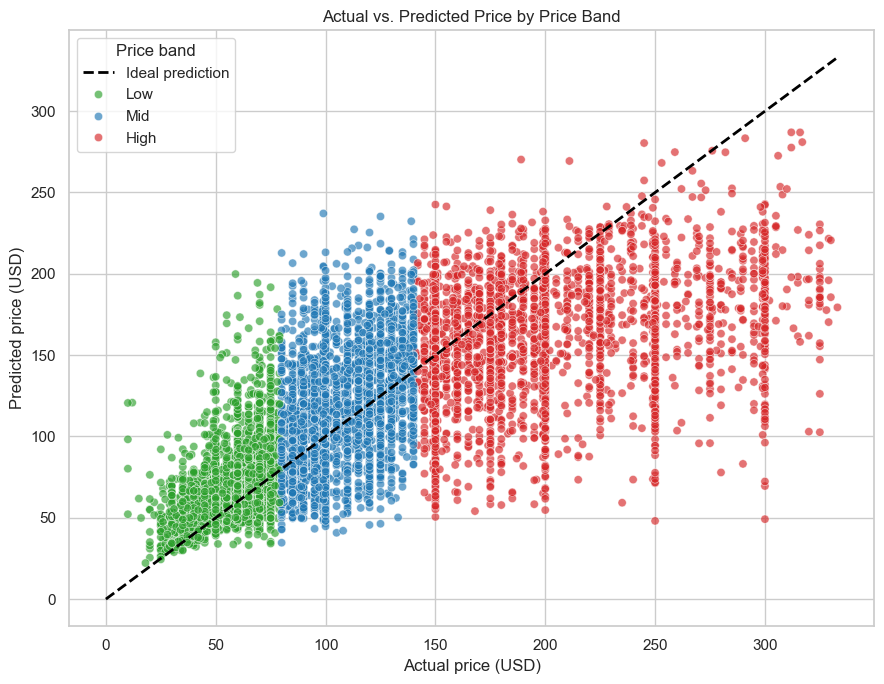

Saved scatter plot to /Users/Kushal/Projects/BNB_Pricing/artifacts/plots/xgboost_actual_vs_predicted_by_band.png


In [3]:
sns.set_theme(style="whitegrid")
fig, axis = plt.subplots(figsize=(9, 7))

maximum_axis_value = max(
    float(evaluation_frame["actual_price"].max()),
    float(evaluation_frame["predicted_price"].max()),
)
axis.plot(
    [0, maximum_axis_value],
    [0, maximum_axis_value],
    linestyle="--",
    linewidth=2,
    color="black",
    label="Ideal prediction",
)
sns.scatterplot(
    data=evaluation_frame,
    x="actual_price",
    y="predicted_price",
    hue="price_band",
    palette=BAND_COLORS,
    alpha=0.65,
    s=36,
    ax=axis,
)
axis.set_title("Actual vs. Predicted Price by Price Band")
axis.set_xlabel("Actual price (USD)")
axis.set_ylabel("Predicted price (USD)")
axis.legend(title="Price band")
fig.tight_layout()
fig.savefig(SCATTER_PLOT_PATH, dpi=180)
plt.show()
print(f"Saved scatter plot to {SCATTER_PLOT_PATH}")

## Top under-priced and over-priced listing examples

This deliverable surfaces the largest pricing gaps on the test split:
- **Under-priced candidates**: model predicts much higher than actual listed price.
- **Over-priced candidates**: model predicts much lower than actual listed price.

The table is exported to CSV for reporting and review.

In [4]:
TOP_MISPRICED_ROWS = 20
MISPRICED_OUTPUT_PATH = PLOTS_DIR.parent / "xgboost_top_mispriced_examples.csv"

mispriced_frame = evaluation_frame.copy()
mispriced_frame["pricing_gap"] = mispriced_frame["predicted_price"] - mispriced_frame["actual_price"]
mispriced_frame["absolute_gap"] = mispriced_frame["pricing_gap"].abs()
mispriced_frame["percent_gap"] = np.where(
    mispriced_frame["actual_price"] > 0,
    (mispriced_frame["pricing_gap"] / mispriced_frame["actual_price"]) * 100.0,
    np.nan,
)

under_priced = mispriced_frame.nlargest(TOP_MISPRICED_ROWS, "pricing_gap").copy()
under_priced["pricing_direction"] = "under_priced_candidate"

over_priced = mispriced_frame.nsmallest(TOP_MISPRICED_ROWS, "pricing_gap").copy()
over_priced["pricing_direction"] = "over_priced_candidate"

top_mispriced_examples = (
    pd.concat([under_priced, over_priced], ignore_index=True)
    .loc[:, [
        "pricing_direction",
        "price_band",
        "actual_price",
        "predicted_price",
        "pricing_gap",
        "absolute_gap",
        "percent_gap",
    ]]
    .sort_values(["pricing_direction", "absolute_gap"], ascending=[True, False])
    .reset_index(drop=True)
)

top_mispriced_examples.to_csv(MISPRICED_OUTPUT_PATH, index=False)
print(f"Saved top mispriced listing examples to {MISPRICED_OUTPUT_PATH}")

display(top_mispriced_examples)

Saved top mispriced listing examples to /Users/Kushal/Projects/BNB_Pricing/artifacts/xgboost_top_mispriced_examples.csv


,pricing_direction,price_band,actual_price,predicted_price,pricing_gap,absolute_gap,percent_gap
0,over_priced_candidate,High,300.0,49.146894,-250.853106,250.853106,-83.617702
1,over_priced_candidate,High,300.0,69.506834,-230.493166,230.493166,-76.831055
2,over_priced_candidate,High,300.0,72.326800,-227.673200,227.673200,-75.891067
3,over_priced_candidate,High,325.0,102.604736,-222.395264,222.395264,-68.429312
4,over_priced_candidate,High,320.0,102.949793,-217.050207,217.050207,-67.828190
5,over_priced_candidate,High,290.0,83.131589,-206.868411,206.868411,-71.333935
6,over_priced_candidate,High,300.0,96.186798,-203.813202,203.813202,-67.937734
7,over_priced_candidate,High,280.0,77.867238,-202.132762,202.132762,-72.190272
8,over_priced_candidate,High,250.0,48.079454,-201.920546,201.920546,-80.768219
9,over_priced_candidate,High,325.0,126.193835,-198.806165,198.806165,-61.171128


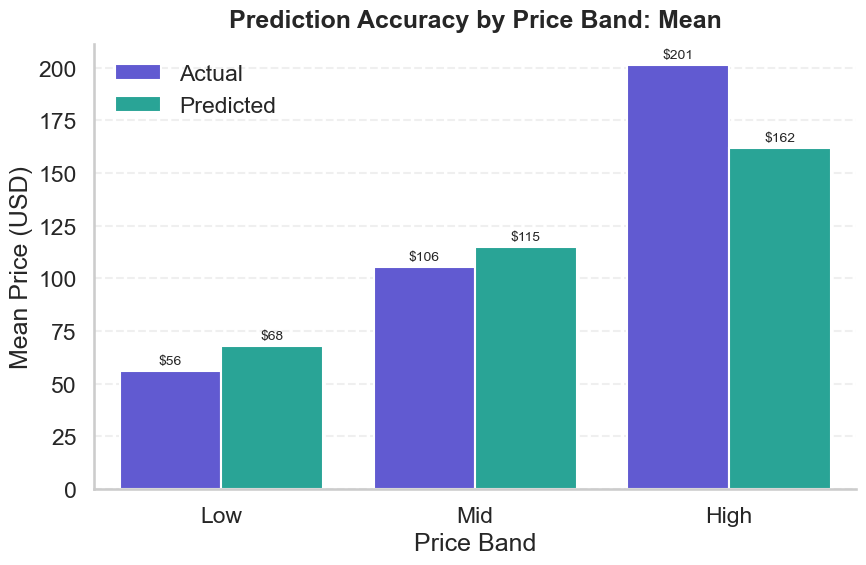

Saved mean price-band bar plot to /Users/Kushal/Projects/BNB_Pricing/artifacts/plots/xgboost_prediction_accuracy_by_band_mean.png


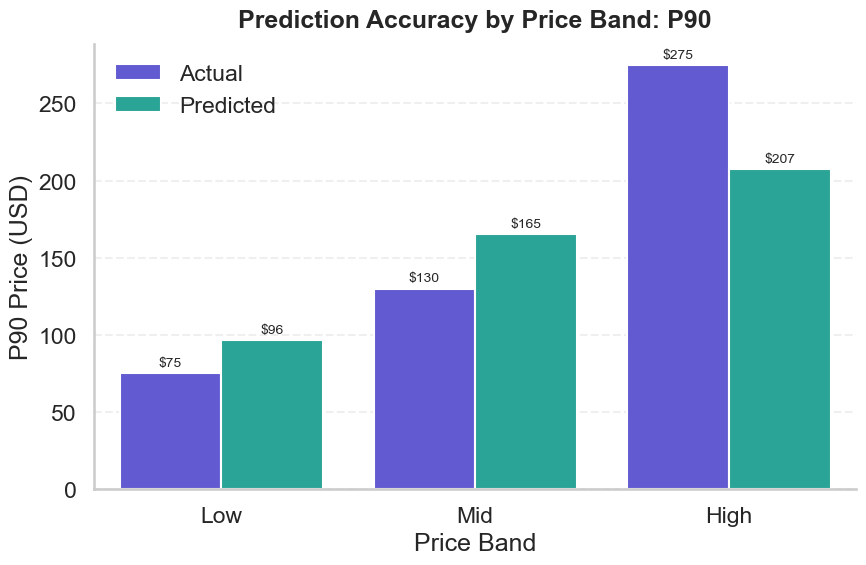

Saved p90 price-band bar plot to /Users/Kushal/Projects/BNB_Pricing/artifacts/plots/xgboost_prediction_accuracy_by_band_p90.png


,actual_mean,predicted_mean,actual_p90,predicted_p90
price_band,,,,
Low,55.819180,67.920814,75.0,96.381139
Mid,105.537236,114.645163,130.0,165.331841
High,201.303928,161.791124,275.0,207.435324


In [5]:
band_summary = (
    evaluation_frame.groupby("price_band", observed=True)
    .apply(
        lambda group: pd.Series(
            {
                "actual_mean": group["actual_price"].mean(),
                "predicted_mean": group["predicted_price"].mean(),
                "actual_p90": group["actual_price"].quantile(0.9),
                "predicted_p90": group["predicted_price"].quantile(0.9),
            }
        ),
        include_groups=False,
    )
    .reindex(BAND_LABELS)
)

mean_plot_frame = (
    band_summary[["actual_mean", "predicted_mean"]]
    .rename(columns={"actual_mean": "Actual", "predicted_mean": "Predicted"})
    .reset_index(names="Price band")
    .melt(id_vars="Price band", var_name="Series", value_name="Price")
)

p90_plot_frame = (
    band_summary[["actual_p90", "predicted_p90"]]
    .rename(columns={"actual_p90": "Actual", "predicted_p90": "Predicted"})
    .reset_index(names="Price band")
    .melt(id_vars="Price band", var_name="Series", value_name="Price")
)

mean_plot_path = PLOTS_DIR / "xgboost_prediction_accuracy_by_band_mean.png"
p90_plot_path = PLOTS_DIR / "xgboost_prediction_accuracy_by_band_p90.png"

sns.set_theme(style="whitegrid", context="talk")
palette = {"Actual": "#4F46E5", "Predicted": "#14B8A6"}

fig_mean, axis_mean = plt.subplots(figsize=(9, 6))
mean_bar_plot = sns.barplot(
    data=mean_plot_frame,
    x="Price band",
    y="Price",
    hue="Series",
    palette=palette,
    ax=axis_mean,
)
for container in mean_bar_plot.containers:
    axis_mean.bar_label(container, fmt="$%.0f", padding=3, fontsize=10)
axis_mean.set_title("Prediction Accuracy by Price Band: Mean", pad=12, fontweight="semibold")
axis_mean.set_xlabel("Price Band")
axis_mean.set_ylabel("Mean Price (USD)")
axis_mean.legend(title="", frameon=False, loc="upper left")
axis_mean.spines["top"].set_visible(False)
axis_mean.spines["right"].set_visible(False)
axis_mean.grid(axis="y", linestyle="--", alpha=0.3)
fig_mean.tight_layout()
fig_mean.savefig(mean_plot_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved mean price-band bar plot to {mean_plot_path}")

fig_p90, axis_p90 = plt.subplots(figsize=(9, 6))
p90_bar_plot = sns.barplot(
    data=p90_plot_frame,
    x="Price band",
    y="Price",
    hue="Series",
    palette=palette,
    ax=axis_p90,
)
for container in p90_bar_plot.containers:
    axis_p90.bar_label(container, fmt="$%.0f", padding=3, fontsize=10)
axis_p90.set_title("Prediction Accuracy by Price Band: P90", pad=12, fontweight="semibold")
axis_p90.set_xlabel("Price Band")
axis_p90.set_ylabel("P90 Price (USD)")
axis_p90.legend(title="", frameon=False, loc="upper left")
axis_p90.spines["top"].set_visible(False)
axis_p90.spines["right"].set_visible(False)
axis_p90.grid(axis="y", linestyle="--", alpha=0.3)
fig_p90.tight_layout()
fig_p90.savefig(p90_plot_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved p90 price-band bar plot to {p90_plot_path}")

band_summary